# Scaling law plots — Canon architecture

X-axis: model size (estimated parameters)  
Y-axis: log loss (`loss/out`) or log task metric (`evals/synthetic/…`)

In [15]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
from plots.utils import (
    TASK_NAMES,
    TASK_METRICS,
    TASK_PRIMARY_METRIC,
    get_wandb_metric_keys,
    wandb_eval_key,
    fetch_runs_results,
    debug_run_summary,
    plot_scaling_law,
    plot_custom_metric,
    plot_task_metrics_grid,
    plot_all_tasks_primary_metrics,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [16]:
WANDB_API_KEY = "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" 
WANDB_ENTITY  = "kirill456z"
WANDB_PROJECT = "physics4llm"

In [17]:
RUN_IDS = {
    "llama": [
    "scaling_law_exps_llama_30m_0.4.72",
    "scaling_law_exps_llama_300m_0.4.71",
    "scaling_law_exps_llama_10m_0.4.70",
    "lr_comp_llama3e-4_0.4.53"
    ],
    "canon": [
    "scaling_law_exps_canon_30m_0.4.69",
    "scaling_law_exps_canon_300m_0.4.68",
    "scaling_law_exps_canon_10m_0.4.67",
    "lr_comp_canon3e-4_0.4.51",
    ]
}

In [18]:
SELECTED_TASKS = TASK_NAMES
METRIC_KEYS = get_wandb_metric_keys(SELECTED_TASKS)

print(f"Fetching {len(METRIC_KEYS)} metric keys:")
for k in METRIC_KEYS:
    print(" ", k)

Fetching 25 metric keys:
  loss/out
  evals/synthetic/concomp_factor_edges_list/accuracy
  evals/synthetic/concomp_factor_edges_list/prefix_accuracy
  evals/synthetic/concomp_factor_edges_list/component_recall
  evals/synthetic/concomp_factor_adj_list/accuracy
  evals/synthetic/concomp_factor_adj_list/prefix_accuracy
  evals/synthetic/concomp_factor_adj_list/component_recall
  evals/synthetic/depo_edges_list/hop_1/accuracy
  evals/synthetic/depo_edges_list/hop_2/accuracy
  evals/synthetic/depo_edges_list/hop_4/accuracy
  evals/synthetic/depo_edges_list/hop_8/accuracy
  evals/synthetic/depo_adj_list/hop_1/accuracy
  evals/synthetic/depo_adj_list/hop_2/accuracy
  evals/synthetic/depo_adj_list/hop_4/accuracy
  evals/synthetic/depo_adj_list/hop_8/accuracy
  evals/synthetic/shortest_path_edges_list/set_accuracy
  evals/synthetic/shortest_path_edges_list/prefix_accuracy
  evals/synthetic/shortest_path_edges_list/is_correct_path
  evals/synthetic/shortest_path_adj_list/set_accuracy
  evals/sy

In [19]:
results_df = fetch_runs_results(
    run_ids=RUN_IDS,
    api_key=WANDB_API_KEY,
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
)

print(f"\nFetched {len(results_df)} runs")
cols = [c for c in ["label", "run_name", "n_params"] if c in results_df.columns]
results_df[cols]


[llama]
  loss/out = 0.2554  (avg of last 100 steps)
  scaling_law_exps_llama_30m_0.4.72         n_params=  10,822,656
  loss/out = 0.1880  (avg of last 100 steps)
  scaling_law_exps_llama_300m_0.4.71        n_params=  85,364,736
  loss/out = 0.4539  (avg of last 100 steps)
  scaling_law_exps_llama_10m_0.4.70         n_params=   3,280,896
  loss/out = 0.2119  (avg of last 100 steps)
  lr_comp_llama3e-4_0.4.53                  n_params=  25,444,352

[canon]
  loss/out = 0.2578  (avg of last 100 steps)
  scaling_law_exps_canon_30m_0.4.69         n_params=  10,887,168
  loss/out = 0.1724  (avg of last 100 steps)
  scaling_law_exps_canon_300m_0.4.68        n_params=  85,622,784
  loss/out = 0.3557  (avg of last 100 steps)
  scaling_law_exps_canon_10m_0.4.67         n_params=   3,309,568
  loss/out = 0.1741  (avg of last 100 steps)
  lr_comp_canon3e-4_0.4.51                  n_params=  25,559,040

Fetched 8 runs


,label,run_name,n_params
0,llama,scaling_law_exps_llama_30m_0.4.72,10822656
1,llama,scaling_law_exps_llama_300m_0.4.71,85364736
2,llama,scaling_law_exps_llama_10m_0.4.70,3280896
3,llama,lr_comp_llama3e-4_0.4.53,25444352
4,canon,scaling_law_exps_canon_30m_0.4.69,10887168
5,canon,scaling_law_exps_canon_300m_0.4.68,85622784
6,canon,scaling_law_exps_canon_10m_0.4.67,3309568
7,canon,lr_comp_canon3e-4_0.4.51,25559040


In [20]:
meta_cols = {"run_id", "run_name", "n_params"}
metric_cols = [c for c in results_df.columns if c not in meta_cols]
print(f"Runs: {len(results_df)}  |  Metric columns: {len(metric_cols)}")
for c in metric_cols:
    non_null = results_df[c].notna().sum()
    print(f"  {c:<60s}  {non_null:>3}/{len(results_df)} runs")

Runs: 8  |  Metric columns: 49
  label                                                           8/8 runs
  _runtime                                                        8/8 runs
  _step                                                           8/8 runs
  _timestamp                                                      8/8 runs
  _wandb                                                          8/8 runs
  acc_step                                                        8/8 runs
  evals/synthetic/bfs_edges_list/has_eos                          8/8 runs
  evals/synthetic/bfs_edges_list/prefix_accuracy                  8/8 runs
  evals/synthetic/bfs_edges_list/set_precision                    8/8 runs
  evals/synthetic/bfs_edges_list/set_recall                       8/8 runs
  evals/synthetic/concomp_factor_edges_list/accuracy              8/8 runs
  evals/synthetic/concomp_factor_edges_list/component_precision    8/8 runs
  evals/synthetic/concomp_factor_edges_list/component_recall      8/

In [21]:
results_df

,run_id,run_name,label,n_params,_runtime,_step,_timestamp,_wandb,acc_step,evals/synthetic/bfs_edges_list/has_eos,...,memory/num_alloc_retries,memory/num_ooms,memory/power_draw,optim/grad_norm,optim/lr,optim/total_tokens,speed/FLOPS,speed/curr_iter_time,speed/data_load_time,speed/wps
0,scaling_law_exps_llama_30m_0.4.72,scaling_law_exps_llama_30m_0.4.72,llama,10822656,10917.513845,80000,1.778926e+09,{'runtime': 10917},0,1,...,0,0,356218,0.381268,0.00003,10485760000,8.922295e+13,0.0853,0.0262,1.095760e+06
1,scaling_law_exps_llama_300m_0.4.71,scaling_law_exps_llama_300m_0.4.71,llama,85364736,17294.782718,80000,1.778958e+09,{'runtime': 17294},0,1,...,0,0,411403,0.244189,0.00003,10485760000,1.519522e+14,0.4382,0.0734,2.628282e+05
2,scaling_law_exps_llama_10m_0.4.70,scaling_law_exps_llama_10m_0.4.70,llama,3280896,6704.017056,80000,1.778922e+09,{'runtime': 6704},0,1,...,0,0,228759,1.215750,0.00003,10485760000,5.720478e+13,0.0382,0.0259,2.001040e+06
3,lr_comp_llama3e-4_0.4.53,lr_comp_llama3e-4_0.4.53,llama,25444352,13495.742010,80000,1.778534e+09,{'runtime': 13495},0,1,...,0,0,360413,0.515509,0.00006,10485760000,1.251499e+14,0.1709,0.0324,6.432357e+05
4,scaling_law_exps_canon_30m_0.4.69,scaling_law_exps_canon_30m_0.4.69,canon,10887168,18102.976288,80000,1.778933e+09,{'runtime': 18102},0,1,...,0,0,410251,0.397240,0.00003,10485760000,5.445262e+13,0.1557,0.0401,6.640802e+05
5,scaling_law_exps_canon_300m_0.4.68,scaling_law_exps_canon_300m_0.4.68,canon,85622784,61482.219750,80000,1.778977e+09,{'runtime': 61482},0,1,...,0,0,356556,0.316364,0.00003,10485760000,1.054692e+14,0.6901,0.0319,1.817092e+05
6,scaling_law_exps_canon_10m_0.4.67,scaling_law_exps_canon_10m_0.4.67,canon,3309568,15965.108459,80000,1.778931e+09,{'runtime': 15965},0,1,...,0,0,107659,1.212031,0.00003,10485760000,1.896257e+13,0.0716,0.0858,6.571024e+05
7,lr_comp_canon3e-4_0.4.51,lr_comp_canon3e-4_0.4.51,canon,25559040,28535.923294,80000,1.778544e+09,{'runtime': 28535},0,1,...,0,0,357527,0.227525,0.00006,10485760000,8.147787e+13,0.2854,0.0389,4.164590e+05


## Loss

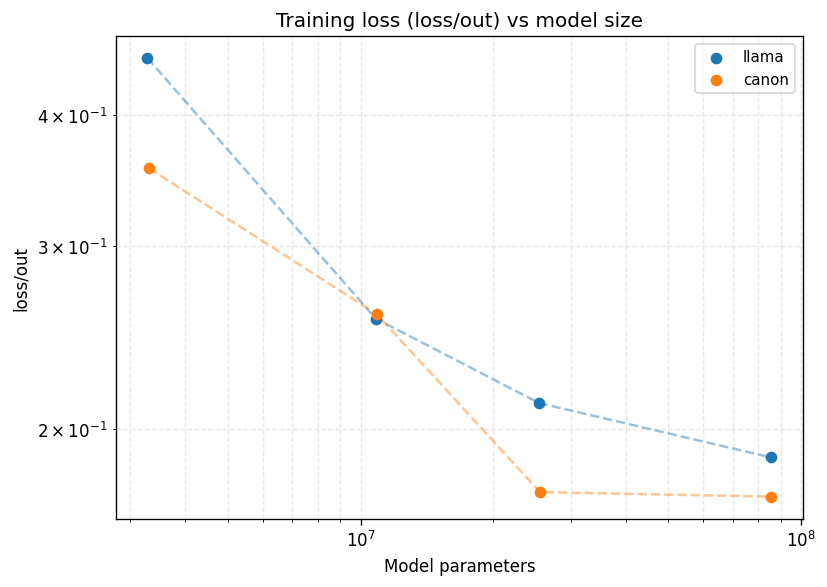

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_scaling_law(
    results_df=results_df,
    metric_key="loss/out",
    ax=ax,
    log_x=True,
    log_y=True,
    title="Training loss (loss/out) vs model size",
)
plt.tight_layout()
plt.show()

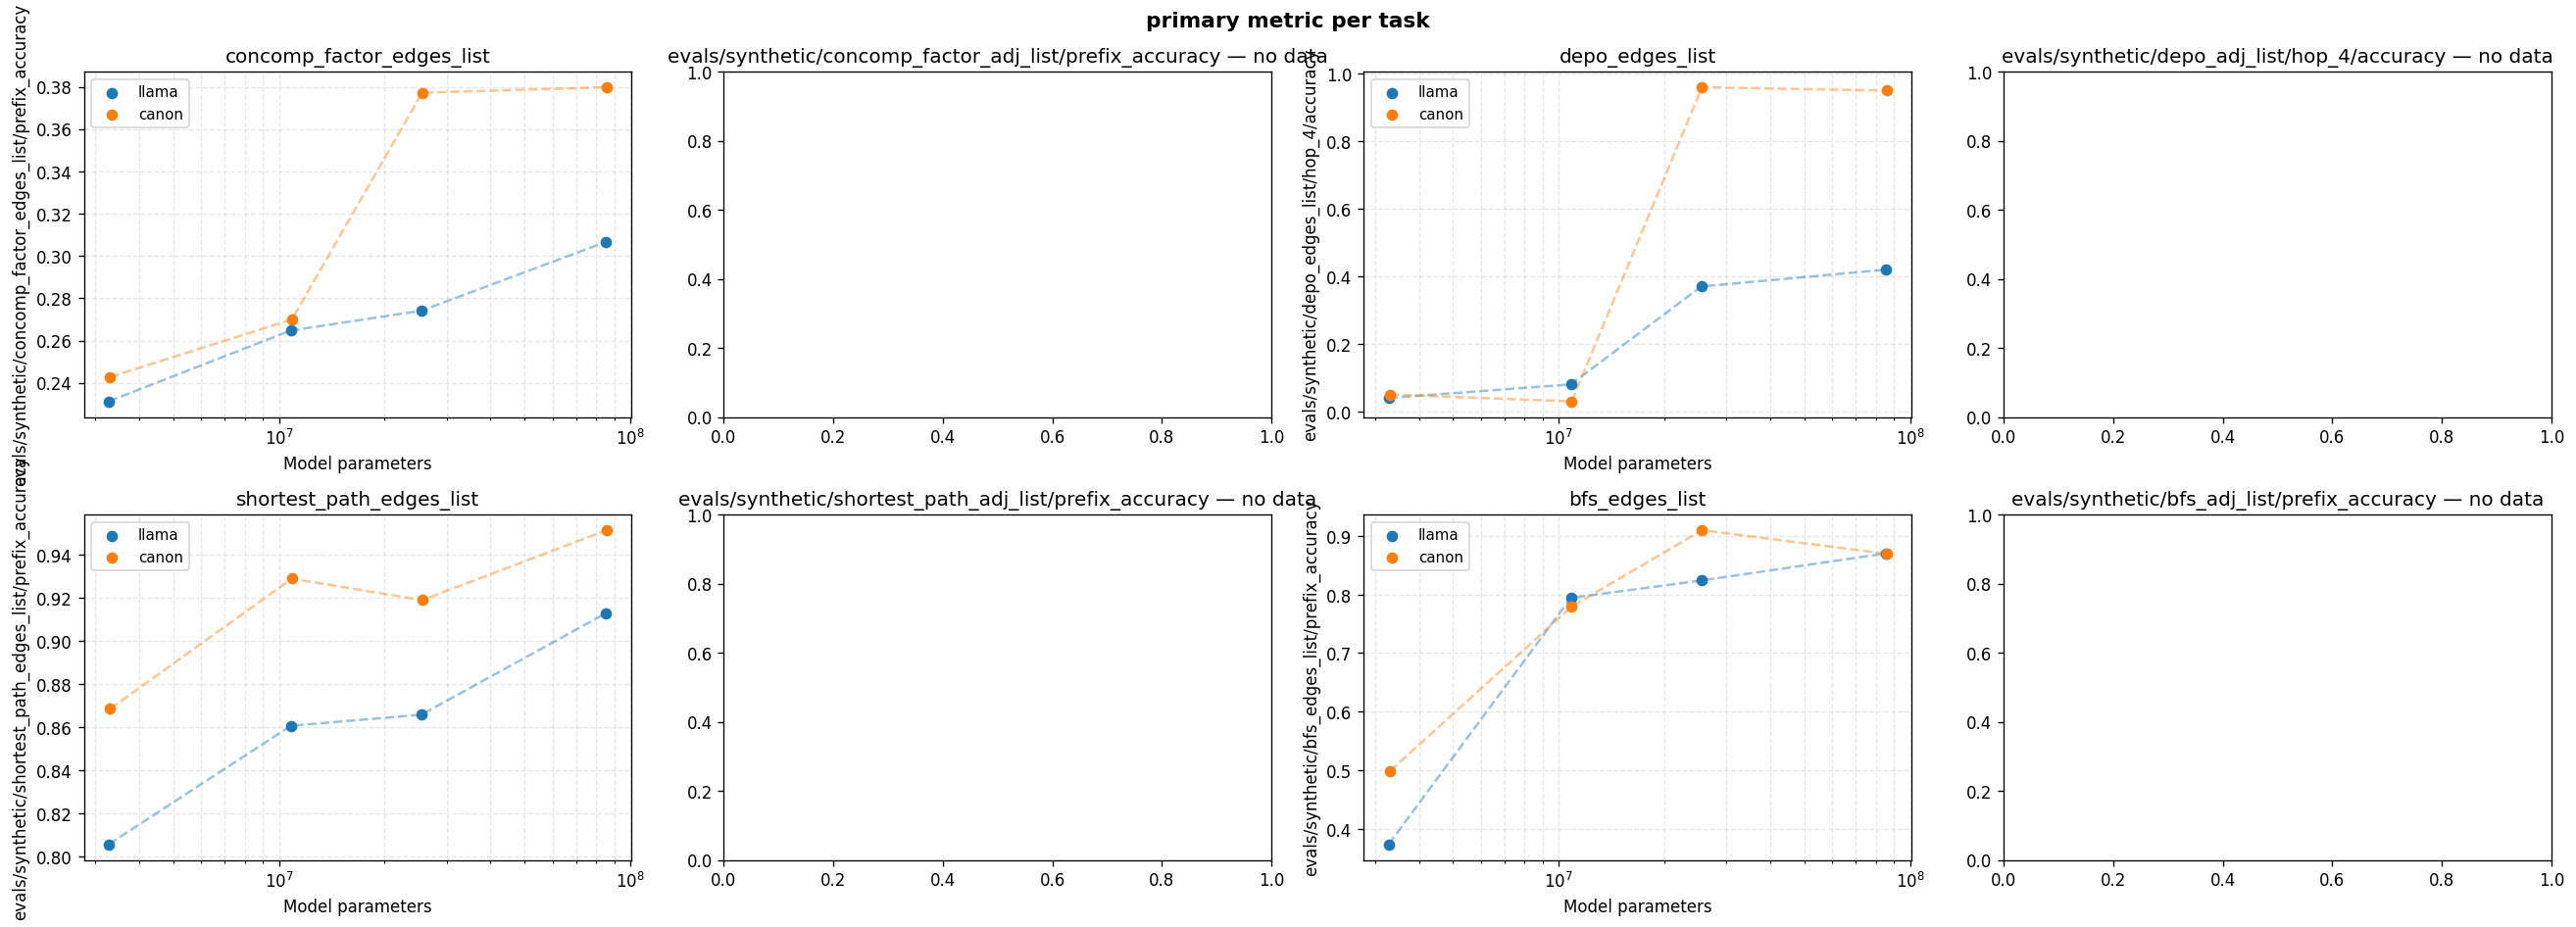

In [23]:
fig = plot_all_tasks_primary_metrics(
    results_df=results_df,
    task_names=SELECTED_TASKS,
    log_x=True,
    log_y=False,  # accuracy is in [0,1] — linear scale is usually more readable
)
plt.show()

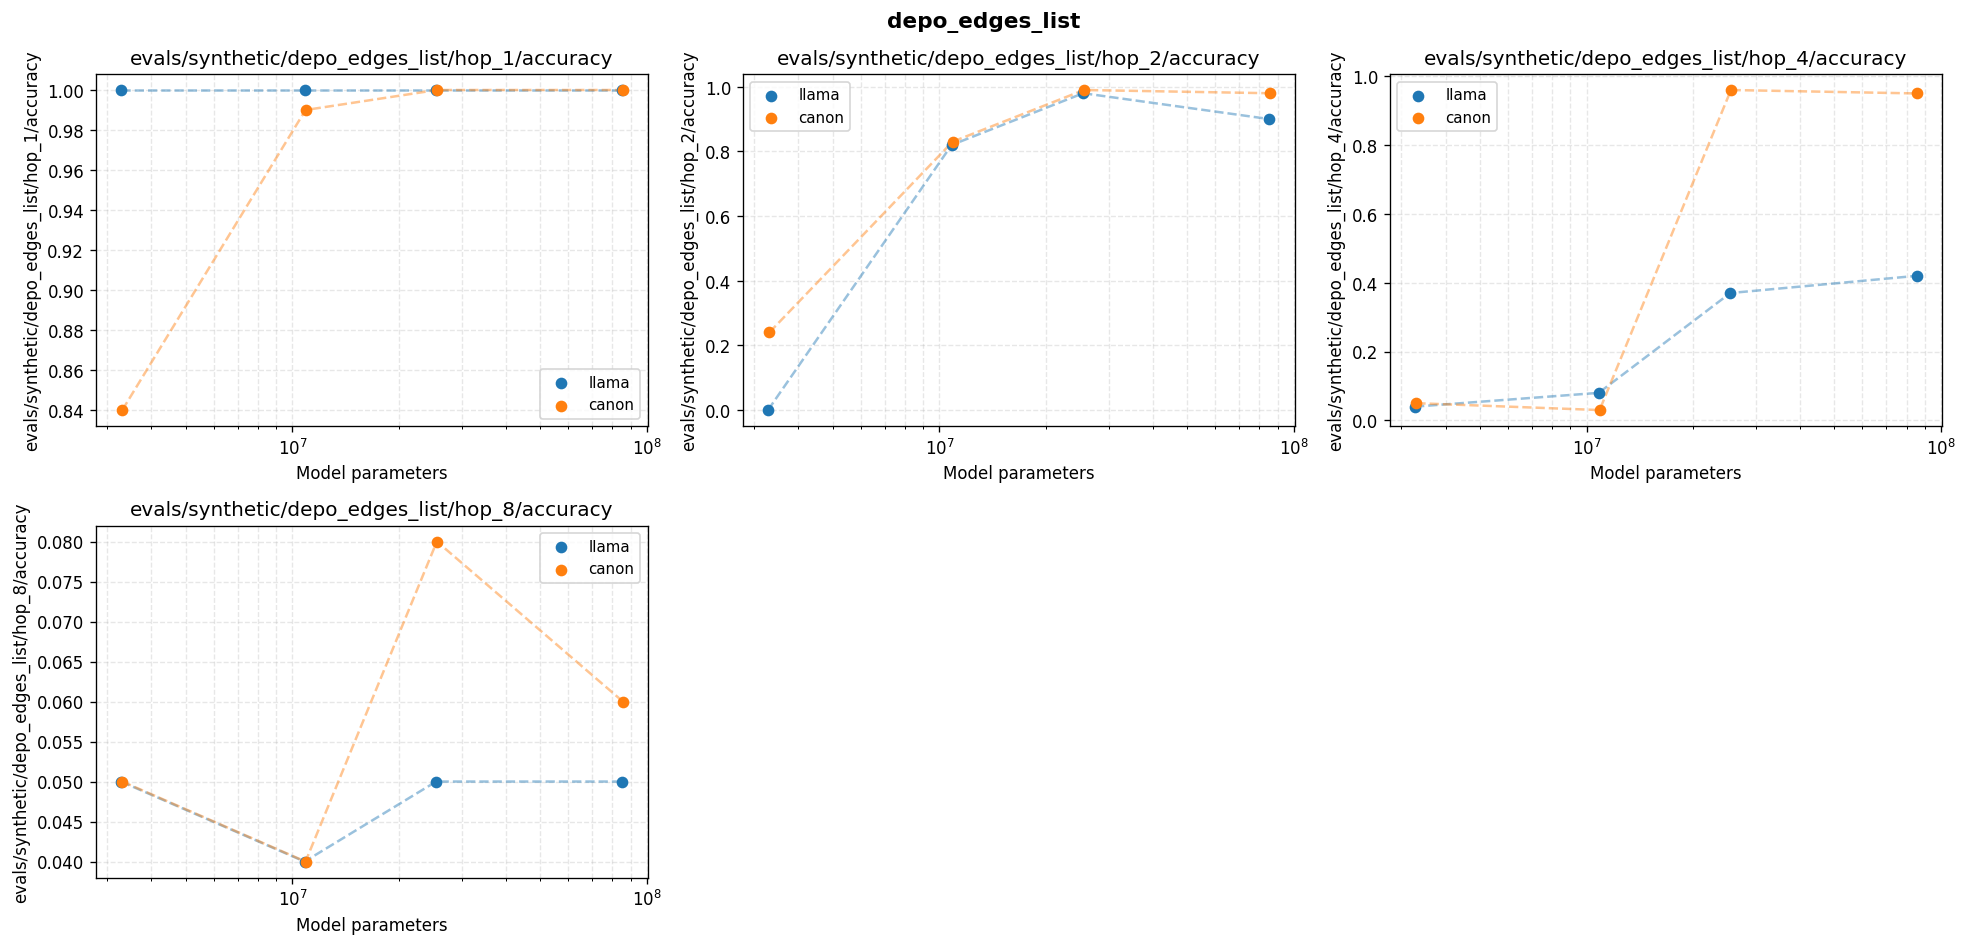

In [24]:
# Depo — all hop levels
for task in ["depo_edges_list"]:
    fig = plot_task_metrics_grid(
        results_df=results_df,
        task_name=task,
        log_x=True,
        log_y=False,
    )
    plt.show()

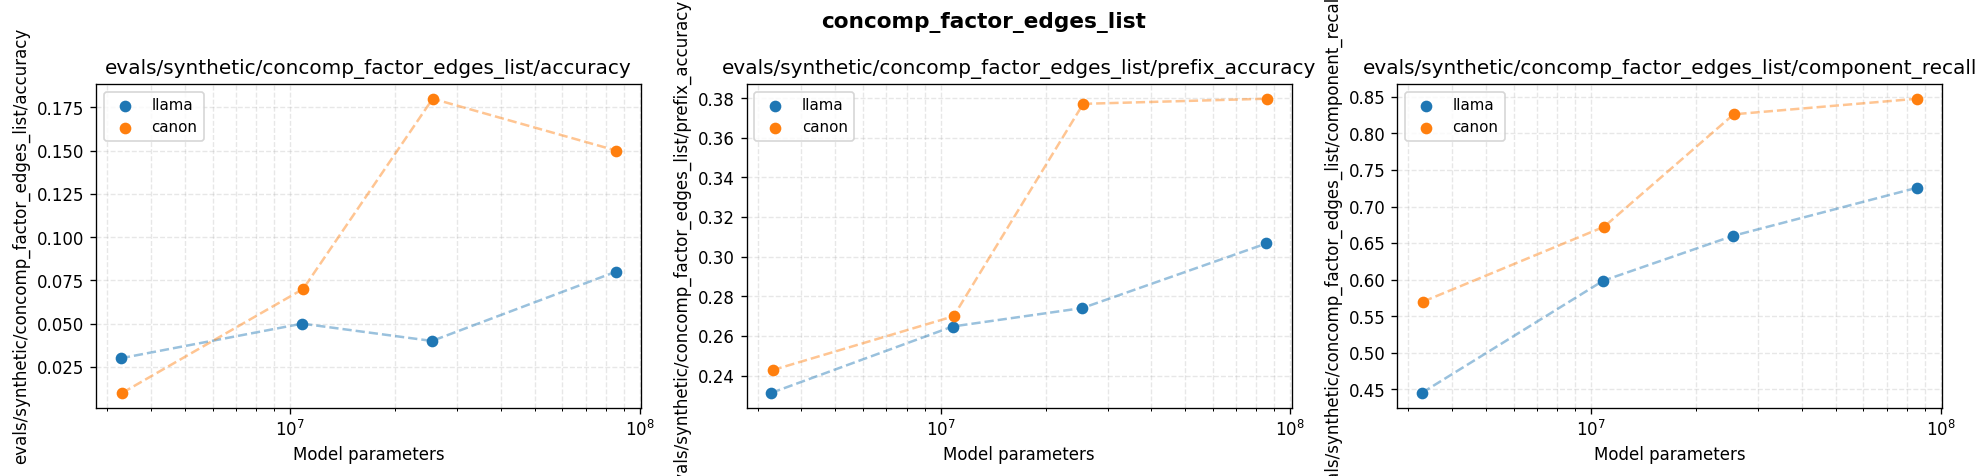

In [25]:
for task in ["concomp_factor_edges_list"]:
    fig = plot_task_metrics_grid(
        results_df=results_df,
        task_name=task,
        log_x=True,
        log_y=False,
    )
    plt.show()

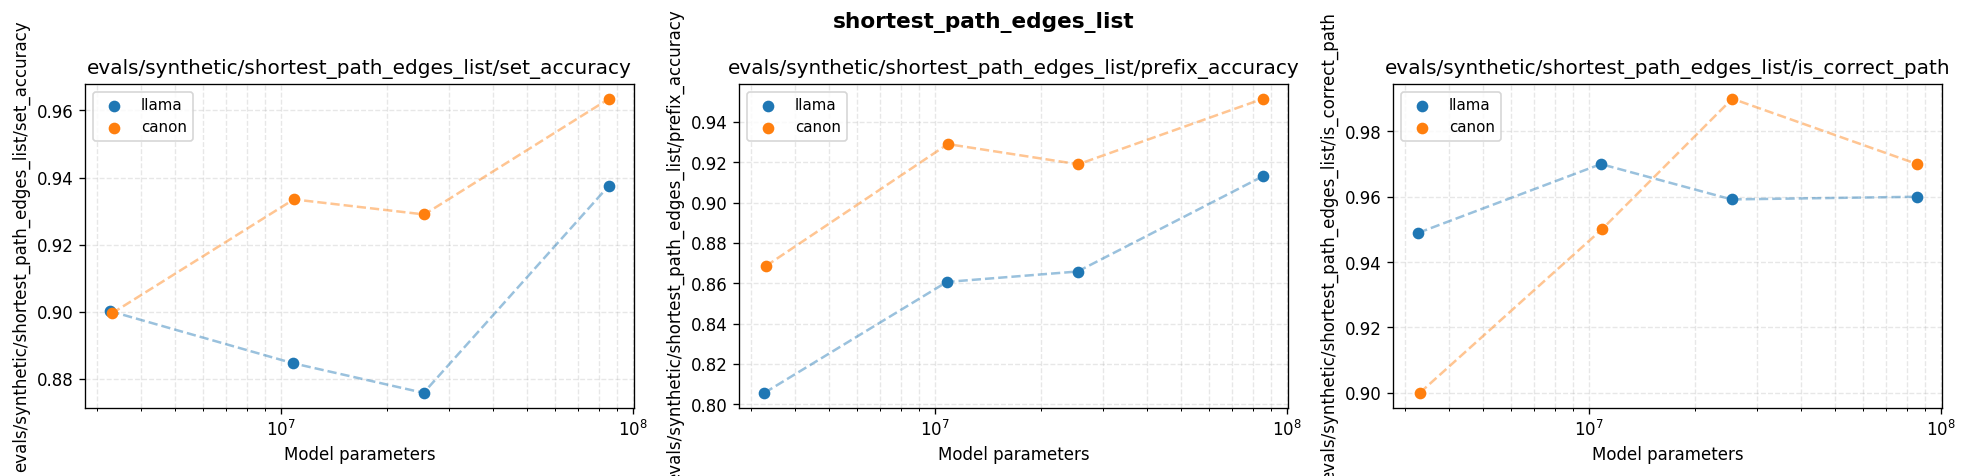

In [26]:
for task in ["shortest_path_edges_list"]:
    fig = plot_task_metrics_grid(
        results_df=results_df,
        task_name=task,
        log_x=True,
        log_y=False,
    )
    plt.show()

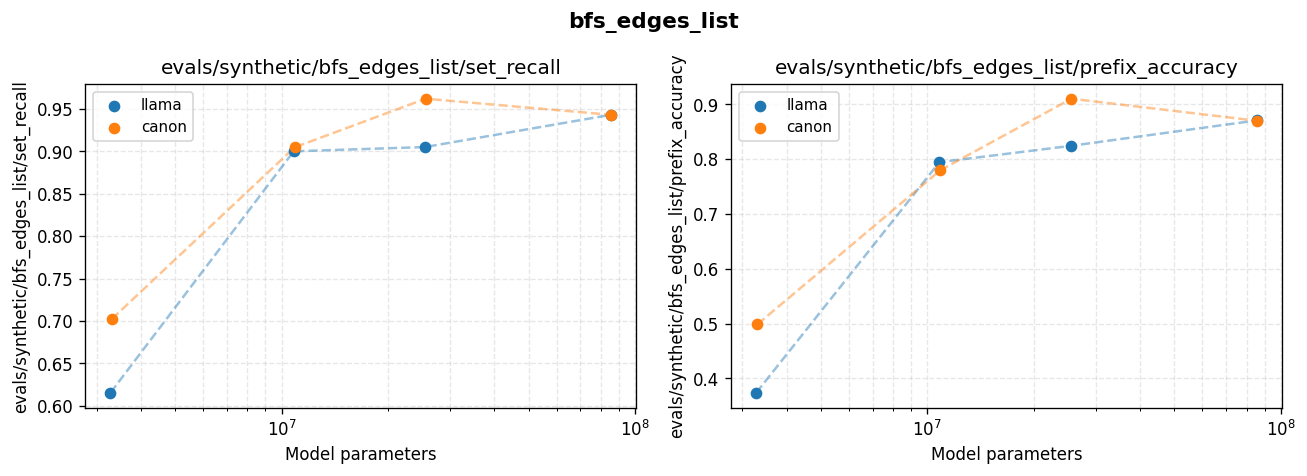

In [27]:
for task in ["bfs_edges_list"]:
    fig = plot_task_metrics_grid(
        results_df=results_df,
        task_name=task,
        log_x=True,
        log_y=False,
    )
    plt.show()

In [32]:
metric_keys = ['evals/synthetic/concomp_factor_edges_list/prefix_accuracy',
 'evals/synthetic/shortest_path_edges_list/prefix_accuracy',
 'evals/synthetic/bfs_edges_list/prefix_accuracy',
 ]

Averaging 4/8 primary metrics:
  evals/synthetic/depo_edges_list/hop_4/accuracy
  evals/synthetic/concomp_factor_edges_list/prefix_accuracy
  evals/synthetic/shortest_path_edges_list/prefix_accuracy
  evals/synthetic/bfs_edges_list/prefix_accuracy


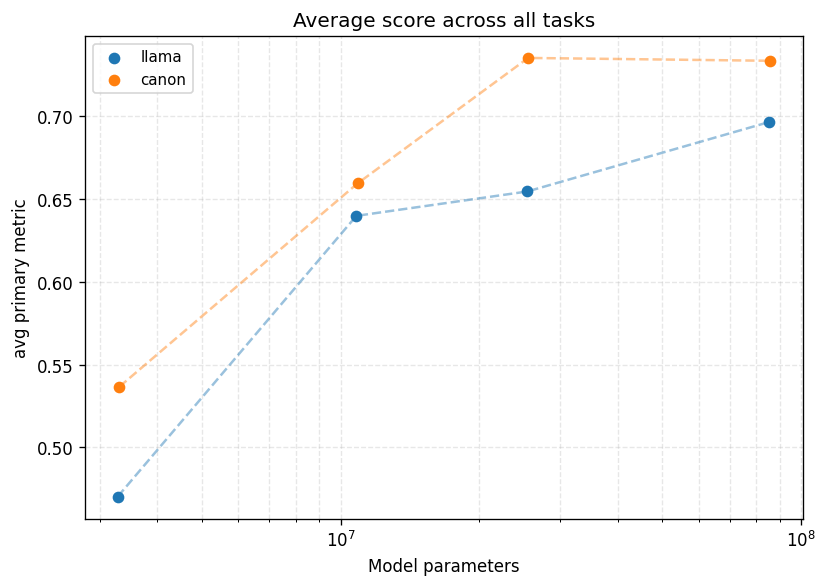

In [33]:
from utils import plot_custom_metric, wandb_eval_key, TASK_PRIMARY_METRIC

primary_keys = [
    wandb_eval_key(task, metric)
    for task, metric in TASK_PRIMARY_METRIC.items()
]
available_keys = [k for k in primary_keys if k in results_df.columns]
print(f"Averaging {len(available_keys)}/{len(primary_keys)} primary metrics:")
for k in available_keys:
    print(f"  {k}")

results_df["avg_primary_metric"] = results_df[metric_keys].mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
plot_custom_metric(
    results_df=results_df,
    metric_values=results_df["avg_primary_metric"],
    metric_name="avg primary metric",
    ax=ax,
    log_x=True,
    log_y=False,
    title="Average score across all tasks",
)
plt.tight_layout()
plt.show()